# Introduction to Nuclear Fuel Burnup and Simple Fuel Composition Changes

This notebook introduces the concept of **nuclear fuel burnup**, its common units, and its relationship to reactor operation. It also uses simple LWR-inspired calculations to show how fuel composition changes during irradiation and how the spatial shape of flux or power causes spatially varying changes in material composition.

## Learning objectives

Students should be able to:

1. Define nuclear fuel burnup and explain its units.
2. Convert between reactor power, operating time, heavy-metal loading, and burnup.
3. Estimate simple changes in fissile inventory during reactor operation.
4. Explain why higher-flux or higher-power regions deplete faster.
5. Use a simple one-dimensional flux or power shape to estimate spatially varying burnup and composition.
6. Describe the physics behind the change of the multiplication factor with burnup.
7. Discuss the impact of batched fuel loading and flux/power distributions on the operation of a nuclear reactor core.

## 1. What is fuel burnup?

**Fuel burnup** is a measure of the energy extracted from nuclear fuel per unit initial heavy-metal mass.

A common unit is:

$$
\text{MWd/tHM}
$$

which means **megawatt-days of thermal energy per metric ton of initial heavy metal**.

For a reactor operating at thermal power $P$ for time $t$, with initial heavy-metal mass $M_{\mathrm{HM}}$,

$$
B = \frac{P t}{M_{\mathrm{HM}}}
$$

where:

- $B$ is burnup,
- $P$ is thermal power,
- $t$ is operating time,
- $M_{\mathrm{HM}}$ is initial heavy-metal mass.

If $P$ is in MW, $t$ is in days, and $M_{\mathrm{HM}}$ is in metric tons, then $B$ is in MWd/tHM.

Typical discharge burnups for modern LWR fuel are often tens of GWd/tHM, where

$$
1\ \mathrm{GWd/tHM}=1000\ \mathrm{MWd/tHM}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def burnup_MWd_per_tHM(power_MWth, time_days, mass_tHM):
    return power_MWth * time_days / mass_tHM

# Example LWR-like values
P_core = 3000.0      # MWth
M_HM = 100.0        # tHM
days = 500.0        # days

B = burnup_MWd_per_tHM(P_core, days, M_HM)
B_GWd = B / 1000

print(f"Burnup = {B:,.0f} MWd/tHM")
print(f"Burnup = {B_GWd:.2f} GWd/tHM")

Burnup = 15,000 MWd/tHM
Burnup = 15.00 GWd/tHM


### Physical interpretation

A burnup of $15\ \mathrm{GWd/tHM}$ means that each metric ton of initial heavy metal has produced the thermal equivalent of

$$
15{,}000\ \mathrm{MWd}
$$

of energy. Burnup therefore combines the effects of **power level**, **operating time**, and **fuel loading** into a single useful measure.

## 2. Energy released per fission and fissions per unit burnup

A useful estimate is that each fission releases about

$$
E_f \approx 200\ \mathrm{MeV}
$$

of recoverable energy.

Converting this to joules:

$$
E_f = 200\ \mathrm{MeV}
\left(1.602\times 10^{-13}\ \frac{\mathrm{J}}{\mathrm{MeV}}\right)
\approx 3.204\times 10^{-11}\ \mathrm{J/fission}.
$$

This lets us estimate how many fissions are needed to produce a given burnup.

In [2]:
E_fission_J = 200.0 * 1.602176634e-13  # J/fission
J_per_MWd = 1.0e6 * 24 * 3600          # J per MWd

fissions_per_MWd = J_per_MWd / E_fission_J
fissions_per_GWd = 1000 * fissions_per_MWd

print(f"Energy per fission = {E_fission_J:.3e} J/fission")
print(f"Fissions per MWd = {fissions_per_MWd:.3e}")
print(f"Fissions per GWd = {fissions_per_GWd:.3e}")

Energy per fission = 3.204e-11 J/fission
Fissions per MWd = 2.696e+21
Fissions per GWd = 2.696e+24


## 3. A simple estimate of fuel consumed by burnup

For a first estimate, suppose all energy comes from fission of a single isotope with atomic mass number $A$. The mass consumed is approximately

$$
m_{\mathrm{consumed}} =
\frac{N_f A}{N_A}
$$

where:

- $N_f$ is the number of fissions,
- $A$ is grams per mole,
- $N_A$ is Avogadro's number.

This is simplified because real LWR fuel contains multiple uranium and plutonium isotopes, and some fissile material is bred during operation.

In [3]:
N_A = 6.02214076e23

def consumed_mass_per_tHM(burnup_GWd_per_tHM, A=235.0):
    fissions = burnup_GWd_per_tHM * fissions_per_GWd
    grams = fissions * A / N_A
    return grams / 1000  # kg

for BU in [10, 30, 50, 60]:
    kg = consumed_mass_per_tHM(BU, A=235)
    print(f"{BU:2.0f} GWd/tHM: approximate fissile mass consumed = {kg:6.2f} kg/tHM")

10 GWd/tHM: approximate fissile mass consumed =  10.52 kg/tHM
30 GWd/tHM: approximate fissile mass consumed =  31.57 kg/tHM
50 GWd/tHM: approximate fissile mass consumed =  52.61 kg/tHM
60 GWd/tHM: approximate fissile mass consumed =  63.13 kg/tHM


### Discussion

The consumed mass may look surprisingly small compared with $1000\ \mathrm{kg}$ of initial heavy metal. That is because nuclear fission releases enormous energy per unit mass.

A useful rule of thumb from the simplified calculation is that **1 GWd/tHM corresponds to roughly 1 kg of heavy nuclei fissioned per metric ton of heavy metal**.

## 4. Initial composition of a simple LWR fuel

Consider a simplified LWR fuel with initial enrichment:

$$
4.5\ \mathrm{w/o}\ ^{235}\mathrm{U}
$$

and the balance as $^{238}\mathrm{U}$. For 1 metric ton of heavy metal:

$$
m_{235,0} = 0.045(1000\ \mathrm{kg}) = 45\ \mathrm{kg}
$$

$$
m_{238,0} = 955\ \mathrm{kg}.
$$

This is a mass-based description. For reaction-rate calculations, it is often more natural to work with **number of atoms**.

In [4]:
M_tHM_kg = 1000.0
enrichment = 0.045

m2350_kg = enrichment * M_tHM_kg
m2380_kg = (1 - enrichment) * M_tHM_kg

def kg_to_atoms(m_kg, A_g_per_mol):
    return (m_kg * 1000 / A_g_per_mol) * N_A

N2350 = kg_to_atoms(m2350_kg, 235.0)
N2380 = kg_to_atoms(m2380_kg, 238.0)

print(f"Initial U-235 mass = {m2350_kg:.1f} kg/tHM")
print(f"Initial U-238 mass = {m2380_kg:.1f} kg/tHM")
print(f"Initial U-235 atoms = {N2350:.3e}")
print(f"Initial U-238 atoms = {N2380:.3e}")

Initial U-235 mass = 45.0 kg/tHM
Initial U-238 mass = 955.0 kg/tHM
Initial U-235 atoms = 1.153e+26
Initial U-238 atoms = 2.416e+27


## 5. A very simple fissile depletion model

A basic depletion equation for a nuclide undergoing neutron absorption is:

$$
\frac{dN}{dt} = -\sigma_a \phi N
$$

where:

- $N$ is the number density or total number of atoms,
- $\sigma_a$ is the microscopic absorption cross section,
- $\phi$ is neutron flux.

If $\sigma_a$ and $\phi$ are constant in time, the solution is:

$$
N(t) = N_0 e^{-\sigma_a \phi t}.
$$

This is useful for showing how flux changes composition. Real fuel depletion includes fission products, plutonium production, resonance absorption, spectrum changes, and many coupled isotopes.

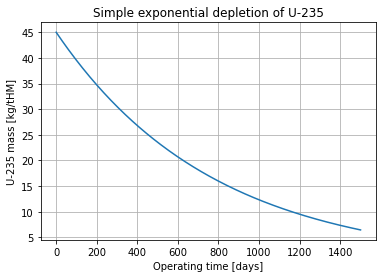

In [5]:
def exponential_depletion(N0, sigma_barns, flux_n_cm2_s, time_days):
    sigma_cm2 = sigma_barns * 1e-24
    t_s = time_days * 24 * 3600
    return N0 * np.exp(-sigma_cm2 * flux_n_cm2_s * t_s)

# Illustrative effective one-group values
sigma_a235_eff = 500.0      # barns
flux = 3.0e13              # n/cm^2-s
times = np.linspace(0, 1500, 301)

N235 = exponential_depletion(N2350, sigma_a235_eff, flux, times)
m235 = N235 / N_A * 235.0 / 1000

plt.figure()
plt.plot(times, m235)
plt.xlabel("Operating time [days]")
plt.ylabel("U-235 mass [kg/tHM]")
plt.title("Simple exponential depletion of U-235")
plt.grid(True)
plt.show()

### Interpretation

This simple model predicts a smooth decrease in $^{235}\mathrm{U}$ inventory. The rate of decrease is faster when:

- the flux $\phi$ is larger,
- the absorption cross section $\sigma_a$ is larger,
- the irradiation time is longer.

In real LWR fuel, not every absorption in $^{235}\mathrm{U}$ is a fission, and other fissile isotopes such as $^{239}\mathrm{Pu}$ are created from $^{238}\mathrm{U}$.

## 6. Linking burnup to power and fissions

Another simple way to model composition change is to relate burnup directly to fissions. If the fuel reaches burnup \(B\), the number of fissions per tHM is approximately:

$$
N_f(B) = 
B
\left(
\frac{1000\ \mathrm{MWd}}{1\ \mathrm{GWd}}
\right)
\left(
\frac{8.64\times 10^{10}\ \mathrm{J}}{1\ \mathrm{MWd}}
\right)
\frac{1}{E_f}.
$$

The mass of heavy nuclei fissioned is then approximately proportional to burnup.

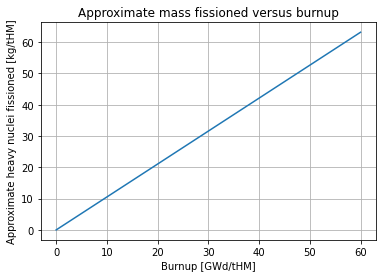

In [6]:
burnups = np.linspace(0, 60, 121)  # GWd/tHM
consumed_kg = np.array([consumed_mass_per_tHM(bu, A=235.0) for bu in burnups])

plt.figure()
plt.plot(burnups, consumed_kg)
plt.xlabel("Burnup [GWd/tHM]")
plt.ylabel("Approximate heavy nuclei fissioned [kg/tHM]")
plt.title("Approximate mass fissioned versus burnup")
plt.grid(True)
plt.show()

## 7. A simple LWR-inspired model: U-235 depletion and Pu-239 buildup

A slightly richer model includes:

1. $^{235}\mathrm{U}$ absorption and fission,
2. $^{238}\mathrm{U}$ absorption leading eventually to $^{239}\mathrm{Pu}$,
3. $^{239}\mathrm{Pu}$ absorption and fission.

The physical chain is approximately:

$$
^{238}\mathrm{U}(n,\gamma) \rightarrow ^{239}\mathrm{U}
\rightarrow ^{239}\mathrm{Np}
\rightarrow ^{239}\mathrm{Pu}.
$$

For a simplified teaching model, we ignore the decay times and write:

$$
\frac{dN_{235}}{dt} = -\sigma_{a,235}\phi N_{235}
$$

$$
\frac{dN_{239}}{dt} =
y_{239}\sigma_{c,238}\phi N_{238}
-
\sigma_{a,239}\phi N_{239}
$$

where $y_{239}$ is an effective yield factor representing the fraction of $^{238}\mathrm{U}$ captures that become $^{239}\mathrm{Pu}$.

For simplicity, we treat $N_{238}$ as approximately constant because only a small fraction of the large $^{238}\mathrm{U}$ inventory is converted over the time scale considered here.

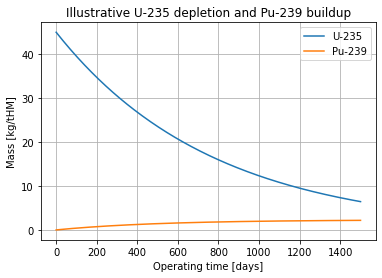

At 1500 days:
  U-235 mass = 6.44 kg/tHM
  Pu-239 mass = 2.18 kg/tHM


In [7]:
def simple_lwr_isotopes(time_days, flux=3.0e13):
    t_s = np.asarray(time_days) * 24 * 3600

    # Illustrative effective one-group microscopic cross sections
    sig_a235 = 500.0e-24
    sig_c238 = 2.0e-24
    sig_a239 = 750.0e-24
    y239 = 0.9

    lam235 = sig_a235 * flux
    lam239 = sig_a239 * flux
    source239 = y239 * sig_c238 * flux * N2380

    N235 = N2350 * np.exp(-lam235 * t_s)
    N239 = (source239 / lam239) * (1 - np.exp(-lam239 * t_s))

    return N235, N239

times = np.linspace(0, 1500, 301)
N235, N239 = simple_lwr_isotopes(times)

m235 = N235 / N_A * 235.0 / 1000
m239 = N239 / N_A * 239.0 / 1000

plt.figure()
plt.plot(times, m235, label="U-235")
plt.plot(times, m239, label="Pu-239")
plt.xlabel("Operating time [days]")
plt.ylabel("Mass [kg/tHM]")
plt.title("Illustrative U-235 depletion and Pu-239 buildup")
plt.legend()
plt.grid(True)
plt.show()

print(f"At {times[-1]:.0f} days:")
print(f"  U-235 mass = {m235[-1]:.2f} kg/tHM")
print(f"  Pu-239 mass = {m239[-1]:.2f} kg/tHM")

### Interpretation

This simplified model shows two important ideas:

1. The original fissile material, $^{235}\mathrm{U}$, is depleted by neutron absorption.
2. A new fissile isotope, $^{239}\mathrm{Pu}$, is produced from neutron capture in $^{238}\mathrm{U}$.

In real LWR fuel, plutonium production helps support power production later in life. This is one reason fuel composition changes cannot be understood from $^{235}\mathrm{U}$ depletion alone.

## 8. Spatial flux and power shape

In a reactor, flux and power are not perfectly uniform. A simple one-dimensional axial flux shape might be approximated as:

$$
\phi(z) = \phi_0 \sin\left(\frac{\pi z}{H}\right),
\qquad 0 \le z \le H.
$$

This shape is largest near the middle of the core and smaller near the ends.

If local power is proportional to local flux, then local burnup is also approximately proportional to local flux:

$$
B(z,t) \propto \phi(z)t.
$$

Therefore, the center of the core tends to burn faster than the ends.

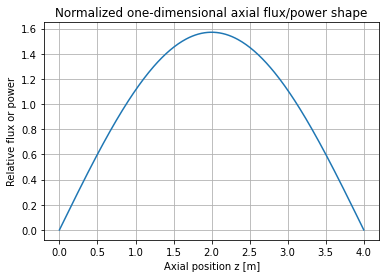

Average of normalized shape = 1.000
Peak-to-average ratio = 1.571


In [8]:
H = 4.0  # m, illustrative active fuel height
z = np.linspace(0, H, 301)

shape = np.sin(np.pi * z / H)
shape_avg = np.trapz(shape, z) / H
normalized_shape = shape / shape_avg

plt.figure()
plt.plot(z, normalized_shape)
plt.xlabel("Axial position z [m]")
plt.ylabel("Relative flux or power")
plt.title("Normalized one-dimensional axial flux/power shape")
plt.grid(True)
plt.show()

print(f"Average of normalized shape = {np.trapz(normalized_shape, z) / H:.3f}")
print(f"Peak-to-average ratio = {normalized_shape.max():.3f}")

### Why normalize the shape?

The normalized shape has an average value of 1. This makes it easy to interpret:

$$
B(z) = \bar{B} f(z)
$$

where:

- $\bar{B}$ is the average burnup,
- $f(z)$ is the normalized flux or power shape,
- the average value of $f(z)$ is 1.

If $f(z)=1.5$ at the center, then the local burnup at the center is 1.5 times the core-average burnup.

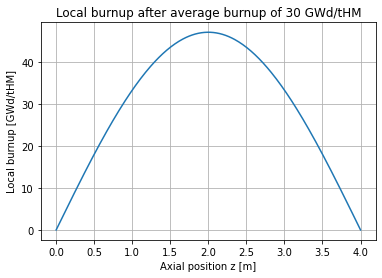

Average burnup = 30.00 GWd/tHM
Maximum local burnup = 47.12 GWd/tHM
Minimum local burnup at ends = 0.00 GWd/tHM


In [9]:
B_avg = 30.0  # GWd/tHM
B_local = B_avg * normalized_shape

plt.figure()
plt.plot(z, B_local)
plt.xlabel("Axial position z [m]")
plt.ylabel("Local burnup [GWd/tHM]")
plt.title("Local burnup after average burnup of 30 GWd/tHM")
plt.grid(True)
plt.show()

print(f"Average burnup = {np.trapz(B_local, z) / H:.2f} GWd/tHM")
print(f"Maximum local burnup = {B_local.max():.2f} GWd/tHM")
print(f"Minimum local burnup at ends = {B_local.min():.2f} GWd/tHM")

## 9. Spatially varying composition change

Now combine the burnup idea with material composition.

Suppose the local mass of $^{235}\mathrm{U}$ decreases approximately according to local burnup. As a simple estimate, assume a fraction of fissions comes from $^{235}\mathrm{U}$. Let

$$
f_{235}
$$

be the fraction of fissions supplied by $^{235}\mathrm{U}$. Then the local $^{235}\mathrm{U}$ mass consumed is approximately

$$
m_{235,\mathrm{consumed}}(z)
=
f_{235}
\left[
\text{heavy nuclei fissioned per unit burnup}
\right]
B(z).
$$

This is a simplified model, but it clearly shows the link between spatial power shape and spatial fuel depletion.

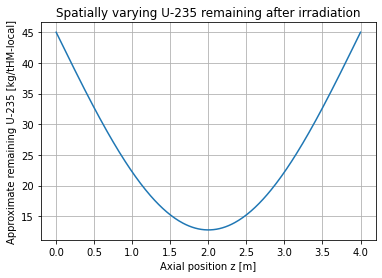

Initial U-235 mass = 45.00 kg/tHM
Minimum remaining U-235 = 12.77 kg/tHM-local
Maximum remaining U-235 = 45.00 kg/tHM-local


In [10]:
f235_fission_fraction = 0.65  # illustrative fraction of fissions from U-235

heavy_fissioned_kg_local = np.array([consumed_mass_per_tHM(bu, A=235.0) for bu in B_local])
m235_consumed_local = f235_fission_fraction * heavy_fissioned_kg_local
m235_remaining_local = m2350_kg - m235_consumed_local

plt.figure()
plt.plot(z, m235_remaining_local)
plt.xlabel("Axial position z [m]")
plt.ylabel("Approximate remaining U-235 [kg/tHM-local]")
plt.title("Spatially varying U-235 remaining after irradiation")
plt.grid(True)
plt.show()

print(f"Initial U-235 mass = {m2350_kg:.2f} kg/tHM")
print(f"Minimum remaining U-235 = {m235_remaining_local.min():.2f} kg/tHM-local")
print(f"Maximum remaining U-235 = {m235_remaining_local.max():.2f} kg/tHM-local")

### Interpretation

The middle of the core has the highest flux and power, so it accumulates the highest burnup. As a result, the center region has the greatest change in fuel composition.

This is the basic reason why real reactor fuel management must consider spatial effects. Fuel assemblies, axial regions, and radial regions do not all experience the same irradiation history.

## 10. Flattening the power shape

Reactor designers often try to avoid excessive power peaking. To see why, compare two normalized power shapes:

1. A peaked sinusoidal shape,
2. A flatter shape.

Both have the same average value, so both produce the same average burnup. However, the peaked shape produces a higher maximum local burnup.

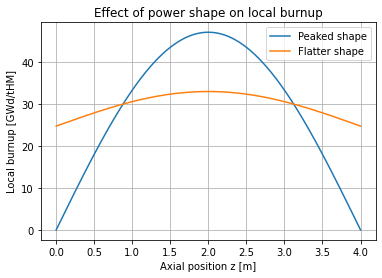

Peaked shape max burnup = 47.12 GWd/tHM
Flatter shape max burnup = 33.00 GWd/tHM


In [11]:
shape_sine = np.sin(np.pi * z / H)
shape_flat = 0.75 + 0.25 * np.sin(np.pi * z / H)

shape_sine_norm = shape_sine / (np.trapz(shape_sine, z) / H)
shape_flat_norm = shape_flat / (np.trapz(shape_flat, z) / H)

B_sine = B_avg * shape_sine_norm
B_flat = B_avg * shape_flat_norm

plt.figure()
plt.plot(z, B_sine, label="Peaked shape")
plt.plot(z, B_flat, label="Flatter shape")
plt.xlabel("Axial position z [m]")
plt.ylabel("Local burnup [GWd/tHM]")
plt.title("Effect of power shape on local burnup")
plt.legend()
plt.grid(True)
plt.show()

print(f"Peaked shape max burnup = {B_sine.max():.2f} GWd/tHM")
print(f"Flatter shape max burnup = {B_flat.max():.2f} GWd/tHM")

### Design interpretation

For the same average burnup, a flatter power distribution reduces the maximum local burnup. This matters because design limits are often associated with local conditions, not just core-average conditions.

A region with high local burnup may have:

- greater fissile depletion,
- more fission product buildup,
- higher local power history,
- reduced margin to material or thermal limits.

This is why power shaping, control rod history, burnable absorbers, and fuel shuffling are important in reactor operation.

## 11. Student exercises

### Exercise 1

A reactor operates at \(3400\ \mathrm{MWth}\) for 18 months. Assume 30 days per month and an initial heavy-metal loading of \(105\ \mathrm{tHM}\).

Calculate the burnup in \(\mathrm{MWd/tHM}\) and \(\mathrm{GWd/tHM}\).

### Exercise 2

Using the approximation that \(1\ \mathrm{GWd/tHM}\) corresponds to about \(1\ \mathrm{kg/tHM}\) of heavy nuclei fissioned, estimate the mass fissioned per tHM at \(45\ \mathrm{GWd/tHM}\).

### Exercise 3

For the axial shape

\[
f(z)=\frac{\sin(\pi z/H)}{\langle \sin(\pi z/H)\rangle},
\]

what is the physical meaning of \(f(z)>1\)? What does it imply about local burnup?

### Exercise 4

Suppose two regions of a fuel rod experience relative fluxes of 1.2 and 0.8 for the same operating time. If the average burnup is \(40\ \mathrm{GWd/tHM}\), estimate the local burnup in each region.

### Exercise 5

Explain why a high-burnup region may not have the same isotopic composition as a low-burnup region, even if both regions started with identical fresh fuel.

## 12. Summary

Fuel burnup measures energy extracted per unit initial heavy-metal mass:

$$
B = \frac{Pt}{M_{\mathrm{HM}}}.
$$

Burnup is connected to the number of fissions, and therefore to changes in fuel composition. Simple depletion models show that nuclide concentrations depend on neutron flux, reaction cross sections, and irradiation time.

Because flux and power vary spatially in a reactor, burnup and fuel composition also vary spatially. Higher-power regions generally experience faster depletion and larger changes in material composition. Understanding this connection is central to reactor design, operation, fuel management, and safety analysis.

## 13. A simple illustration of multiplication factor versus burnup

The multiplication factor \(k\) measures whether the neutron population tends to increase, decrease, or remain steady from one generation to the next.

- If $k>1$, the system is **supercritical**.
- If $k=1$, the system is **critical**.
- If $k<1$, the system is **subcritical**.

A real power reactor is operated very close to $k_{\mathrm{eff}}=1$, with control rods, soluble boron, burnable absorbers, temperature feedback, and other effects used to maintain criticality. However, the **uncontrolled excess multiplication factor** of the fuel changes with burnup.

Fresh LWR fuel generally has more excess reactivity than burned fuel. As burnup increases, fissile material is depleted, fission products accumulate, plutonium is produced and later depleted, and the net multiplication factor changes.

For a simple teaching model, represent the uncontrolled fuel multiplication factor as:

$$
k_{\infty}(B)
=
k_0
-
aB
+
b\left(1-e^{-B/B_{\mathrm{Pu}}}\right)
-
c\left(1-e^{-B/B_{\mathrm{FP}}}\right).
$$

This is not a predictive reactor physics model. It is a compact way to show competing physical effects: fissile depletion lowers reactivity, plutonium buildup can partly offset that loss early in life, and fission products reduce reactivity.

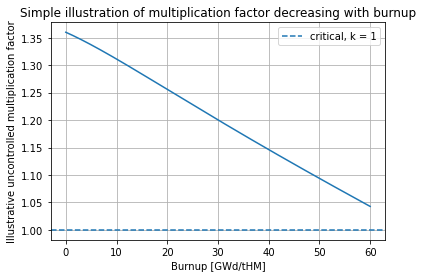

k at fresh fuel, B=0:      1.360
k at B=20 GWd/tHM:        1.256
k at B=40 GWd/tHM:        1.146
k at B=60 GWd/tHM:        1.043


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def simple_k_inf(B):
    # Simple illustrative multiplication factor model versus burnup.
    # B is burnup in GWd/tHM.
    k0 = 1.36
    a = 0.0048
    b = 0.060
    B_pu = 12.0
    c = 0.095
    B_fp = 22.0
    return k0 - a*B + b*(1 - np.exp(-B/B_pu)) - c*(1 - np.exp(-B/B_fp))

B = np.linspace(0, 60, 301)
k = simple_k_inf(B)

plt.figure()
plt.plot(B, k)
plt.axhline(1.0, linestyle="--", label="critical, k = 1")
plt.xlabel("Burnup [GWd/tHM]")
plt.ylabel("Illustrative uncontrolled multiplication factor")
plt.title("Simple illustration of multiplication factor decreasing with burnup")
plt.legend()
plt.grid(True)
plt.show()

print(f"k at fresh fuel, B=0:      {simple_k_inf(0):.3f}")
print(f"k at B=20 GWd/tHM:        {simple_k_inf(20):.3f}")
print(f"k at B=40 GWd/tHM:        {simple_k_inf(40):.3f}")
print(f"k at B=60 GWd/tHM:        {simple_k_inf(60):.3f}")

### Interpretation

This curve should be read qualitatively. It shows that fuel which begins with relatively high excess multiplication factor becomes less reactive as energy is extracted.

A reactor operator does not simply allow \(k\) to drift downward during a cycle. Instead, the core is controlled so that the operating reactor remains critical:

$$
k_{\mathrm{eff}} \approx 1.
$$

The important lesson is that **fuel burnup changes the reactivity worth of the fuel**, which affects fuel management and core loading patterns.

## 14. Why use fuel batches?

In many LWRs, the entire core is not replaced at once. Instead, only a fraction of the fuel is discharged and replaced during a refueling outage.

A simplified three-batch fuel-management scheme contains:

1. **Fresh fuel**: newly loaded fuel with low burnup and high reactivity.
2. **Once-burned fuel**: fuel that has completed one cycle.
3. **Twice-burned fuel**: fuel that has completed two cycles and is near discharge.

A typical simplified equilibrium cycle might use approximate batch-average burnups such as:

$$
B_{\mathrm{fresh}} \approx 0\ \mathrm{GWd/tHM},
$$

$$
B_{\mathrm{once}} \approx 20\ \mathrm{GWd/tHM},
$$

$$
B_{\mathrm{twice}} \approx 40\ \mathrm{GWd/tHM}.
$$

After another cycle, the twice-burned fuel may be discharged, the once-burned fuel becomes twice-burned, the fresh fuel becomes once-burned, and new fresh fuel is loaded.

Fresh       : burnup =    0 GWd/tHM, illustrative k = 1.360
Once-burned : burnup =   20 GWd/tHM, illustrative k = 1.256
Twice-burned: burnup =   40 GWd/tHM, illustrative k = 1.146


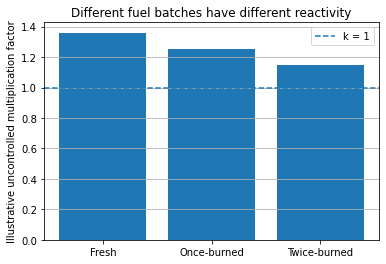

In [13]:
batch_names = ["Fresh", "Once-burned", "Twice-burned"]
batch_burnups = np.array([0.0, 20.0, 40.0])
batch_k = simple_k_inf(batch_burnups)

for name, bu, kval in zip(batch_names, batch_burnups, batch_k):
    print(f"{name:12s}: burnup = {bu:4.0f} GWd/tHM, illustrative k = {kval:.3f}")

plt.figure()
plt.bar(batch_names, batch_k)
plt.axhline(1.0, linestyle="--", label="k = 1")
plt.ylabel("Illustrative uncontrolled multiplication factor")
plt.title("Different fuel batches have different reactivity")
plt.legend()
plt.grid(axis="y")
plt.show()

### Physical interpretation

Fresh fuel is usually more reactive than burned fuel. If all fresh fuel were placed together in one highly important region of the core, the local power could become too high. Fuel management therefore uses spatial arrangement to balance competing goals:

- maintain enough excess reactivity for the cycle,
- avoid excessive local power peaking,
- achieve desired discharge burnup,
- preserve safety margins,
- make efficient use of partially burned fuel.

The exact loading pattern is a detailed design problem, but the basic idea can be illustrated with a simple core map.

## 15. A simple three-batch core map

The following cartoon model represents a core as a small two-dimensional grid. Each location contains a fuel assembly belonging to one of three batches.

This is **not** a real LWR loading pattern, but it illustrates the concept that fuel assemblies with different burnups are placed in different core locations.

We will use:

- 0 = fresh fuel,
- 1 = once-burned fuel,
- 2 = twice-burned fuel.

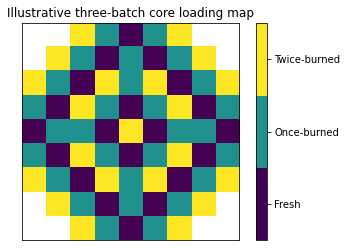

In [14]:
core_batches = np.array([
    [-1, -1,  2,  1,  0,  1,  2, -1, -1],
    [-1,  2,  1,  0,  1,  0,  1,  2, -1],
    [ 2,  1,  0,  2,  1,  2,  0,  1,  2],
    [ 1,  0,  2,  1,  0,  1,  2,  0,  1],
    [ 0,  1,  1,  0,  2,  0,  1,  1,  0],
    [ 1,  0,  2,  1,  0,  1,  2,  0,  1],
    [ 2,  1,  0,  2,  1,  2,  0,  1,  2],
    [-1,  2,  1,  0,  1,  0,  1,  2, -1],
    [-1, -1,  2,  1,  0,  1,  2, -1, -1],
])

masked = np.ma.masked_where(core_batches < 0, core_batches)

plt.figure()
cmap = plt.get_cmap("viridis", 3)
im = plt.imshow(masked, cmap=cmap, vmin=-0.5, vmax=2.5)
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Fresh", "Once-burned", "Twice-burned"])
plt.title("Illustrative three-batch core loading map")
plt.xticks([])
plt.yticks([])
plt.show()

### What this map is meant to show

The map is a conceptual picture of fuel management:

- fuel assemblies are not all at the same burnup,
- fresh fuel is mixed with partially burned fuel,
- burned fuel can be used to help shape the power distribution,
- the loading pattern changes from cycle to cycle.

Real LWR loading patterns are constrained by many additional factors, including control rod locations, burnable absorbers, thermal limits, shutdown margin, leakage, assembly design, and detailed neutronic calculations.

## 16. Combining fuel batch reactivity with spatial importance

Fuel location matters because the neutron flux is not spatially uniform. Fuel placed near the center of the core may experience a larger flux than fuel near the periphery.

A simple radial importance shape can illustrate this:

$$
F(r) = 1 + A\left(1-\frac{r^2}{R^2}\right).
$$

This shape is largest near the center and smaller near the edge. In a real core, the power distribution depends on the coupled neutronics of all assemblies, but this simple model helps show why location matters.

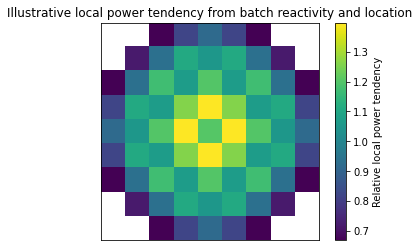

Average relative power tendency = 1.000
Maximum relative power tendency = 1.397
Minimum relative power tendency = 0.669


In [15]:
n = core_batches.shape[0]
x = np.arange(n) - (n - 1) / 2
y = np.arange(n) - (n - 1) / 2
X, Y = np.meshgrid(x, y)
r2 = X**2 + Y**2
R2 = np.max(r2[core_batches >= 0])

A = 0.8
importance = 1 + A * (1 - r2/R2)
importance = np.where(core_batches >= 0, importance, np.nan)

batch_reactivity = {
    0: simple_k_inf(0.0),
    1: simple_k_inf(20.0),
    2: simple_k_inf(40.0),
}

reactivity_map = np.full_like(importance, np.nan, dtype=float)
for batch_id, kval in batch_reactivity.items():
    reactivity_map[core_batches == batch_id] = kval

power_tendency = importance * reactivity_map
power_tendency = power_tendency / np.nanmean(power_tendency)

plt.figure()
im = plt.imshow(power_tendency)
plt.colorbar(im, label="Relative local power tendency")
plt.title("Illustrative local power tendency from batch reactivity and location")
plt.xticks([])
plt.yticks([])
plt.show()

print(f"Average relative power tendency = {np.nanmean(power_tendency):.3f}")
print(f"Maximum relative power tendency = {np.nanmax(power_tendency):.3f}")
print(f"Minimum relative power tendency = {np.nanmin(power_tendency):.3f}")

### Interpretation

This simple calculation combines two ideas:

1. **Fuel history matters:** fresh, once-burned, and twice-burned fuel have different reactivity.
2. **Location matters:** the same assembly can have a different effect depending on where it is placed in the flux shape.

In real core design, the power distribution is found by solving the neutron diffusion or transport equation with detailed cross sections. Still, this toy model captures the essential intuition:

$$
\text{local power} \sim \text{fuel reactivity} \times \text{spatial importance}.
$$

Fuel management is partly the art and science of arranging fuel with different burnups so that the reactor has enough reactivity while keeping local power peaking within acceptable limits.

## 17. Cycle-to-cycle batch movement

In an idealized three-batch scheme, each batch remains in the core for three cycles:

| Cycle status at beginning | End-of-cycle status |
|---|---|
| Fresh | Once-burned |
| Once-burned | Twice-burned |
| Twice-burned | Discharged |

This means the fuel composition and reactivity distribution are deliberately managed over multiple cycles, not just during a single operating cycle.

In [16]:
cycle_table = {
    "Batch at beginning of cycle": ["Fresh", "Once-burned", "Twice-burned"],
    "Approximate beginning burnup [GWd/tHM]": [0, 20, 40],
    "Approximate end burnup [GWd/tHM]": [20, 40, 60],
    "Next step": ["Becomes once-burned", "Becomes twice-burned", "Discharged"],
}

for i in range(3):
    print(f"{cycle_table['Batch at beginning of cycle'][i]:12s} "
          f"{cycle_table['Approximate beginning burnup [GWd/tHM]'][i]:2d} -> "
          f"{cycle_table['Approximate end burnup [GWd/tHM]'][i]:2d} GWd/tHM: "
          f"{cycle_table['Next step'][i]}")

Fresh         0 -> 20 GWd/tHM: Becomes once-burned
Once-burned  20 -> 40 GWd/tHM: Becomes twice-burned
Twice-burned 40 -> 60 GWd/tHM: Discharged


## 18. Key takeaways

The multiplication factor changes with burnup because fuel composition changes. Fresh fuel has more excess reactivity than burned fuel, while burned fuel contains less fissile material and more neutron-absorbing fission products.

LWR cores usually contain fuel batches with different irradiation histories. A simplified three-batch core includes fresh, once-burned, and twice-burned fuel. These batches are arranged spatially to help balance reactivity, power peaking, leakage, and fuel utilization.

The central conceptual link is:

$$
\text{burnup} \rightarrow \text{composition change} \rightarrow \text{reactivity change} \rightarrow \text{fuel management strategy}.
$$